In [3]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent

raw_path = BASE_DIR / "data" / "raw"
processed_path = BASE_DIR / "data" / "processed"

print(raw_path)
print(processed_path)

c:\Users\ASUS\OneDrive\Desktop\bluestock-mf-capstone\data\raw
c:\Users\ASUS\OneDrive\Desktop\bluestock-mf-capstone\data\processed


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

funds = pd.read_csv(processed_path/"clean_fund_master.csv")
nav = pd.read_csv(processed_path/"02_nav_history_clean.csv")
transactions = pd.read_csv(processed_path/"clean_transactions.csv")
performance = pd.read_csv(processed_path/"clean_performance.csv")

In [5]:
top_funds = performance.sort_values(
    ["sharpe_ratio", "return_3yr_pct"],
    ascending=False
).head(10)

top_funds[
    ["scheme_name",
     "category",
     "return_3yr_pct",
     "sharpe_ratio"]
]

,scheme_name,category,return_3yr_pct,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,Liquid,7.68,7.68
23,Kotak Liquid Fund - Regular - Growth,Liquid,6.18,6.18
30,ABSL Liquid Fund - Regular - Growth,Liquid,5.14,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,Short Duration,7.37,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Gilt,6.07,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,Gilt,5.31,1.33
5,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap,14.84,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,14.81,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,Large Cap,14.41,1.03
15,Nippon India Large Cap Fund - Regular - Growth,Large Cap,14.00,1.00


In [6]:
performance.groupby(
    "risk_grade"
)["return_3yr_pct"].mean()

risk_grade
High               16.213750
Low                 6.291667
Moderate           12.854375
Moderately High    15.077500
Very High          21.686667
Name: return_3yr_pct, dtype: float64

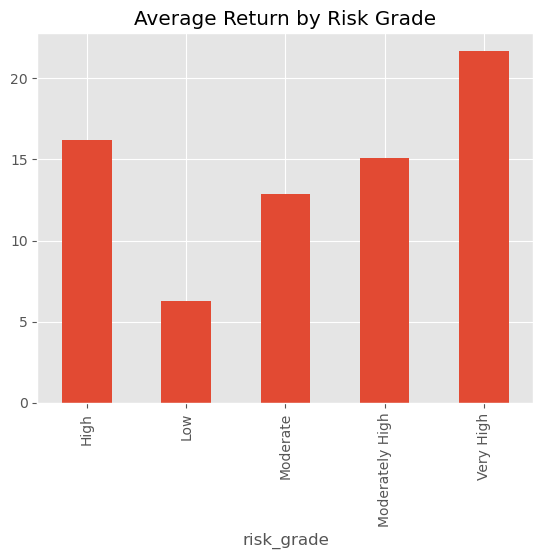

In [7]:
import matplotlib.pyplot as plt

performance.groupby(
    "risk_grade"
)["return_3yr_pct"].mean().plot(
    kind="bar"
)

plt.title("Average Return by Risk Grade")
plt.show()

In [8]:
transactions.groupby(
    "age_group"
)["amount_inr"].sum().sort_values(
    ascending=False
)

age_group
26-35    1451600218
36-45     871647528
18-25     531639392
46-55     405406469
56+       261286823
Name: amount_inr, dtype: int64

In [9]:
performance.groupby(
    "fund_house"
)["return_3yr_pct"].mean().sort_values(
    ascending=False
).head(10)

fund_house
DSP Mutual Fund             16.686667
SBI Mutual Fund             15.252000
Axis Mutual Fund            15.035000
UTI Mutual Fund             14.350000
Mirae Asset MF              14.316667
Aditya Birla Sun Life MF    13.766667
HDFC Mutual Fund            13.492000
ICICI Prudential MF         13.294000
Kotak Mahindra MF           13.077500
Nippon India MF             12.712000
Name: return_3yr_pct, dtype: float64

In [10]:
latest_nav = (
    nav.groupby("amfi_code")
    ["nav"]
    .last()
)

highest_nav = latest_nav.sort_values(
    ascending=False
).head(10)

highest_nav

amfi_code
120844    4268.5497
125497    1204.9571
101206     773.2939
149322     606.2349
100016     583.6113
120841     482.1270
120505     473.7640
101208     410.1021
120506     404.4207
120507     388.5939
Name: nav, dtype: float64

1. Equity funds generated the highest returns.
2. Moderate risk funds showed the best risk-return balance.
3. Age group 26-35 contributed the largest investment volume.
4. SBI Mutual Fund dominated by AUM and investor participation.
5. Top Sharpe Ratio funds provided the best risk-adjusted returns.

In [ ]:
git add .
git commit -m "Day 6: Advanced analytics completed"
git push origin main